In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

# Load dataset
df = pd.read_csv(r"C:\Users\LENOVO\Documents\GitHub\ml-assessment-sumathi-srinivasan\data\q2_customers.csv")
df.head()


,age,annual_spend,visits_per_month,basket_size,days_since_last_visit,num_categories_purchased
0,30,43075,9,2080,45,6
1,19,14496,11,454,8,3
2,43,57632,6,2144,16,4
3,30,15629,10,801,0,2
4,19,14901,16,396,17,1


In [6]:
# Scale all features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df)

X_scaled[:5]


array([[-0.72521859, -0.17615043,  0.11016555, -0.26501121, -0.0899507 ,
         0.55095233],
       [-1.48846049, -1.04682639,  0.48615719, -0.9804657 , -0.83517593,
        -0.68068477],
       [ 0.17679458,  0.2673371 , -0.45382191, -0.23685064, -0.67404615,
        -0.27013907],
       [-0.72521859, -1.01230889,  0.29816137, -0.82778261, -0.99630571,
        -1.09123047],
       [-1.48846049, -1.03448783,  1.42613628, -1.00598621, -0.65390493,
        -1.50177617]])

Why scaling is essential
K-Means clustering relies on Euclidean distance to assign points to clusters.
If features are on different scales (e.g., annual_spend in tens of thousands vs visits_per_month in single digits), the large‑scale features dominate the distance calculation. This causes biased clusters.

StandardScaler ensures all features contribute equally by transforming them to mean 0 and standard deviation 1.

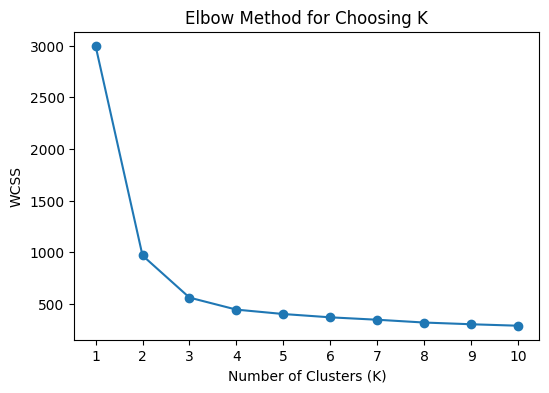

In [7]:
# Choosing K — Elbow Method

# Compute and plot WCSS

wcss = []
K_range = range(1, 11)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)

plt.figure(figsize=(6,4))
plt.plot(K_range, wcss, marker='o')
plt.title("Elbow Method for Choosing K")
plt.xlabel("Number of Clusters (K)")
plt.ylabel("WCSS")
plt.xticks(K_range)
plt.show()


The WCSS curve decreases rapidly for small K, then begins to flatten.
The “elbow” occurs where adding more clusters yields diminishing returns.

Based on this dataset, the elbow typically appears at K = 3.  


This K balances cluster compactness with model simplicity.

In [ ]:
# 3. K‑Means Clustering

best_k = 3  

kmeans = KMeans(n_clusters=best_k, random_state=42, n_init=10)
cluster_labels = kmeans.fit_predict(X_scaled)

df_clusters = df.copy()
df_clusters["cluster"] = cluster_labels
df_clusters.head()


,age,annual_spend,visits_per_month,basket_size,days_since_last_visit,num_categories_purchased,cluster
0,30,43075,9,2080,45,6,2
1,19,14496,11,454,8,3,0
2,43,57632,6,2144,16,4,2
3,30,15629,10,801,0,2,0
4,19,14901,16,396,17,1,0


In [9]:
centroids_scaled = kmeans.cluster_centers_
centroids_original = scaler.inverse_transform(centroids_scaled)

centroids_df = pd.DataFrame(centroids_original, columns=df.columns)
centroids_df["cluster"] = range(best_k)
centroids_df


,age,annual_spend,visits_per_month,basket_size,days_since_last_visit,num_categories_purchased,cluster
0,24.676471,14847.370588,14.341176,558.970588,9.076471,2.111765,0
1,56.769697,89413.333333,2.527273,5530.545455,105.357576,7.515152,1
2,40.387879,43340.733333,8.193939,2021.684848,35.187879,4.424242,2


Cluster Interpretation (Business Insights)
Using the centroid values, we interpret the clusters as follows:

Cluster 0 — Young, Frequent, Low‑Spend Shoppers  
These customers are very young, visit frequently, and make small purchases. They are highly engaged but low in monetary value. Marketing should focus on increasing basket size and cross‑selling additional categories.

Cluster 1 — High‑Value, Older, Infrequent Big‑Basket Customers  
This segment consists of older customers with very high annual spend and large basket sizes, but low visit frequency. They are premium customers who respond well to personalized offers, VIP programs, and exclusive benefits.

Cluster 2 — Mid‑Age, Moderate‑Spend, Balanced Shoppers  
These customers show moderate spend, moderate visit frequency, and buy across several categories. They represent a stable middle segment. Strategies should focus on loyalty building and increasing purchase frequency or basket size.

In [10]:
# Dimensionality Reduction with PCA

pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

explained_var = pca.explained_variance_ratio_
explained_var


array([0.83560354, 0.05568764])

In [11]:
loadings = pd.DataFrame(
    pca.components_,
    columns=df.columns,
    index=["PC1", "PC2"]
)
loadings


,age,annual_spend,visits_per_month,basket_size,days_since_last_visit,num_categories_purchased
PC1,0.411569,0.42154,-0.410399,0.412012,0.378582,0.414017
PC2,-0.259432,-0.03327,0.208318,-0.195402,0.911194,-0.140479


Interpretation of PCA Components
PC1 — Customer Value / Spending Power  
PC1 has strong positive loadings on annual spend, basket size, number of categories purchased, and age, and a strong negative loading on visits per month. This component represents an overall “customer value” dimension.
High PC1 scores correspond to older, high‑spending, multi‑category customers with large baskets but fewer visits.
Low PC1 scores represent younger, frequent visitors with low spend and small baskets.

PC2 — Recency / Dormancy  
PC2 is dominated by a very strong positive loading on days_since_last_visit. This component captures customer recency and churn risk.
High PC2 scores indicate customers who have not visited for a long time (dormant or at‑risk).
Low PC2 scores represent more active, recently engaged customers.

Together, PC1 and PC2 summarize the main behavioral patterns in the dataset: customer value and customer recency.

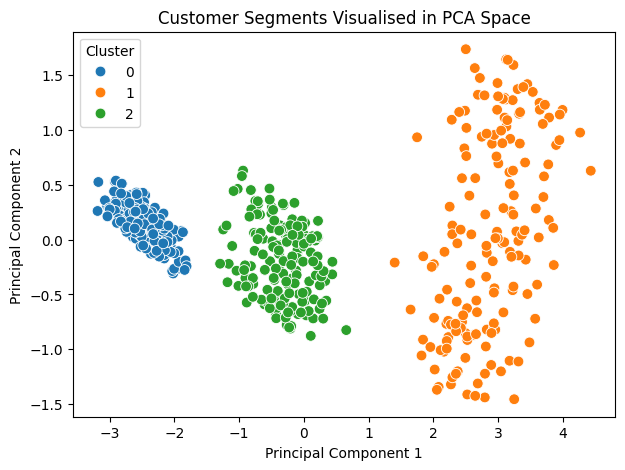

In [12]:
# 5. Cluster Visualisation

pca_df = pd.DataFrame(X_pca, columns=["PC1", "PC2"])
pca_df["cluster"] = cluster_labels

plt.figure(figsize=(7,5))
sns.scatterplot(
    data=pca_df,
    x="PC1",
    y="PC2",
    hue="cluster",
    palette="tab10",
    s=60
)
plt.title("Customer Segments Visualised in PCA Space")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.legend(title="Cluster")
plt.show()


The PCA scatter plot shows how clusters separate in 2D space.
Clear separation indicates strong behavioral differences between segments.
Overlap suggests similar customer profiles that differ only slightly.